# Capítulo 8: Autovalores y Autovectores

In [1]:
# Ejercicio 1
import warnings
import numpy as np

# Desactiva RuntimeWarning de NumPy en toda la sesión
warnings.filterwarnings("ignore", category=RuntimeWarning)

---

### 8.1.

---

### 8.2.

Autovalores: [3.55051026 8.44948974]
Autovectores:
[[-0.91209559 -0.21927526]
 [ 0.40997761 -0.97566304]]


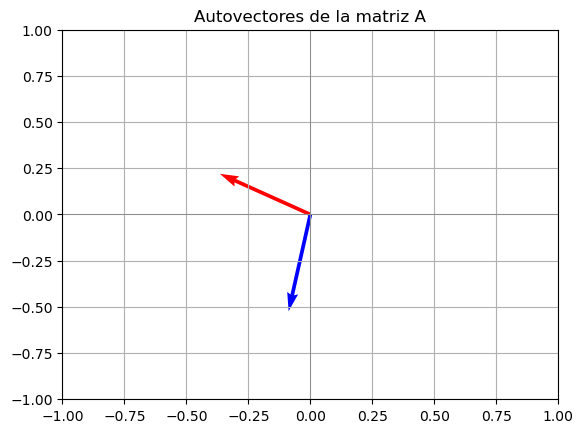

In [ ]:
# Ejercicio 2
import numpy as np
import matplotlib.pyplot as plt

# Definir la matriz A
A = np.array([[4, 1],
              [2, 8]])

# Calcular autovalores y autovectores
autovalores, autovectores = np.linalg.eig(A)
print("Autovalores:", autovalores)
print("Autovectores:")
print(autovectores)

# Graficar los autovectores
origin = np.array([[0, 0], [0, 0]])  # origen para los vectores
plt.quiver(*origin, autovectores[0, :], autovectores[1, :], color=['r','b'], scale=5)
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.grid()
plt.title('Autovectores de la matriz A')
plt.show()

Autovalores: [6.70156212 2.         0.29843788]
Autovectores:
[[ 0.79455357  0.57735027 -0.07677195]
 [ 0.51583922 -0.57735027 -0.29563198]
 [ 0.3203038  -0.57735027  0.95221206]]


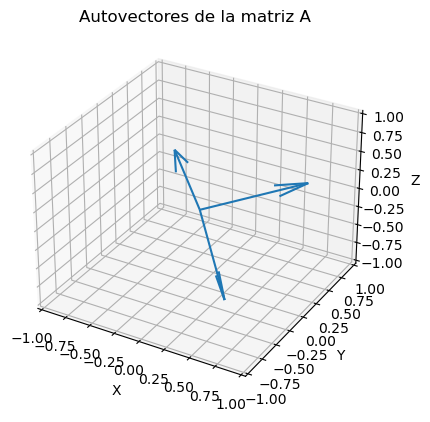

In [ ]:
# Ejercicio 3
import numpy as np
import matplotlib.pyplot as plt

# Definir la matriz A
A = np.array([[5, 2, 1],
              [2, 3, 1],
              [1, 2, 1]])

# Calcular autovalores y autovectores
autovalores, autovectores = np.linalg.eig(A)
print("Autovalores:", autovalores)
print("Autovectores:")
print(autovectores)

# Graficar los autovectores en 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
origin = np.zeros((3, 1))  # origen para los vectores
for i in range(3):
    ax.quiver(*origin.flatten(), *autovectores[:, i], length=1, normalize=True)
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Autovectores de la matriz A')
plt.show()

A * v: [0.56927252 0.25458641]
lambda * v: [0.56927252 0.25458641]
Son iguales: True


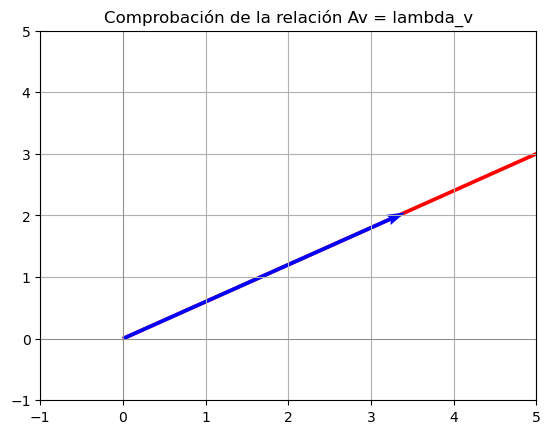

In [ ]:
# Ejercicio 4
import numpy as np
import matplotlib.pyplot as plt

# Definir la matriz A
A = np.array([[0.4, 0.5],
              [0.1, 0.4]])

# Calcular autovalores y autovectores
autovalores, autovectores = np.linalg.eig(A)

# Comprobar la relación Av = lambda_v para el primer autovalor y autovector
v = autovectores[:, 0]
lambda_var = autovalores[0]
Av = np.dot(A, v)
lambda_v = lambda_var * v
print("A * v:", Av)
print("lambda * v:", lambda_v)
print("Son iguales:", np.allclose(Av, lambda_v))

# Graficar Av y lambda_v para visualizar la comprobación
origin = np.array([[0, 0], [0, 0]])  # origen para los vectores
plt.quiver(*origin, [v[0], Av[0]], [v[1], Av[1]], color=['r','b'], scale=1)
plt.xlim(-1, 5)
plt.ylim(-1, 5)
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.grid()
plt.title('Comprobación de la relación Av = lambda_v')
plt.show()

Autovalores: [1.00000000000000, 5.00000000000000]
Autovectores:
Matrix([[-0.333333333333333], [1]])
Matrix([[1.00000000000000], [1]])


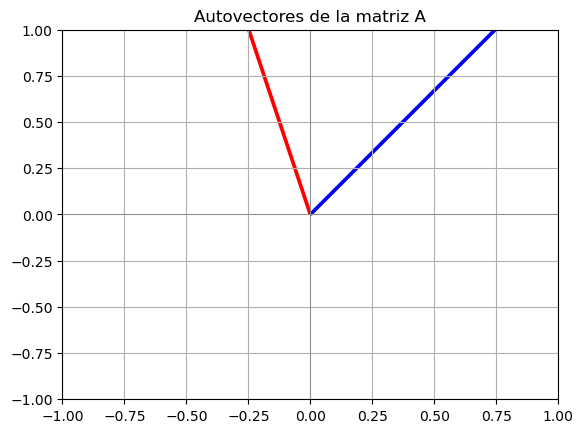

In [ ]:
# Ejercicio 5
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# Definir la matriz A
A = np.array([[4, 1],
              [3, 2]])

# Definir la variable simbólica lambda
lambda_var = sp.symbols('lambda')

# Calcular la matriz A - lambdaI
I = np.eye(2)
A_lambdaI = A - lambda_var * I

# Calcular el determinante de A - lambdaI
det_A_lambdaI = sp.det(sp.Matrix(A_lambdaI))

# Resolver la ecuación característica det(A - lambdaI) = 0
autovalores = sp.solve(det_A_lambdaI, lambda_var)
print("Autovalores:", autovalores)

# Calcular los autovectores correspondientes
autovectores = []
for val in autovalores:
    A_valI = A - val * I
    nullspace = sp.Matrix(A_valI).nullspace()
    if nullspace:  # Verificar si nullspace no está vacío
        v = nullspace[0]
        autovectores.append(v)

print("Autovectores:")
for vec in autovectores:
    print(vec)
if autovectores:
    # Convertir autovalores y autovectores a formato numpy para graficar
    autovalores = np.array([float(val) for val in autovalores])
    autovectores = np.array([np.array(vec).astype(np.float64).flatten() for vec in autovectores]).T

    # Graficar los autovectores
    origin = np.zeros((2, autovectores.shape[1]))  # origen para los vectores
    plt.quiver(*origin, autovectores[0, :], autovectores[1, :], color=['r', 'b'], scale=1)
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.axhline(0, color='grey', lw=0.5)
    plt.axvline(0, color='grey', lw=0.5)
    plt.grid()
    plt.title('Autovectores de la matriz A')
    plt.show()
else:
    print("No se encontraron autovectores.")

### 8.3.

Polinomio Característico: lambda**2 - 4.0*lambda + 3


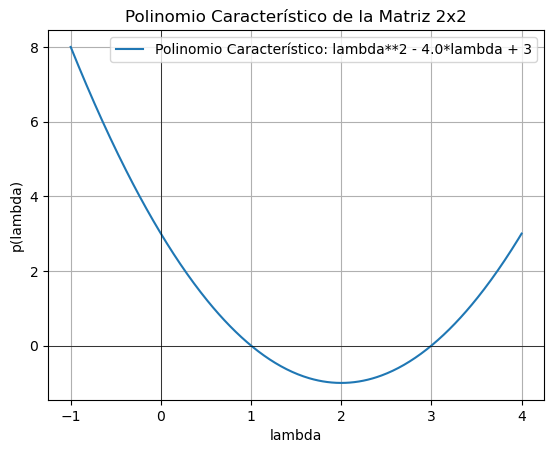

In [ ]:
# Ejercicio 6
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Definir la matriz
A = np.array([[2, 1], [1, 2]])

# Calcular el polinomio característico
lambda_var = sp.Symbol('lambda')
I = np.eye(2)
char_poly = sp.Matrix(A - lambda_var * I).det()

# Simplificar y mostrar el polinomio característico
char_poly = sp.simplify(char_poly)
print(f"Polinomio Característico: {char_poly}")

# Graficar el polinomio característico
p = sp.lambdify(lambda_var, char_poly, 'numpy')
x = np.linspace(-1, 4, 400)
y = p(x)

plt.figure()
plt.plot(x, y, label=f'Polinomio Característico: {char_poly}')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('lambda')
plt.ylabel('p(lambda)')
plt.title('Polinomio Característico de la Matriz 2x2')
plt.legend()
plt.grid(True)
plt.show()

Polinomio Característico: -1.0*lambda**3 + 9.0*lambda**2 - 21.0*lambda + 18


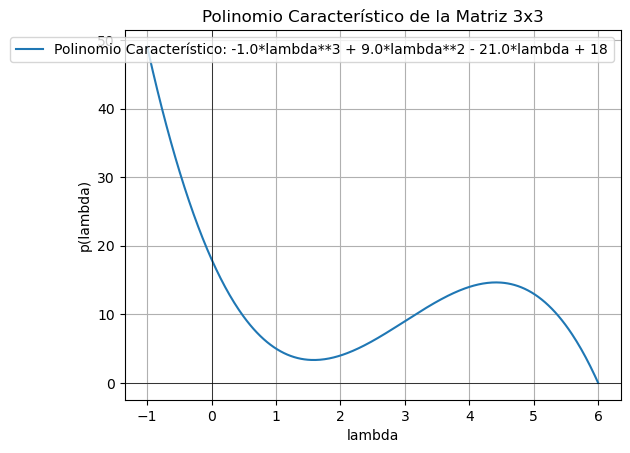

In [ ]:
# Ejercicio 7
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Definir la matriz
A = np.array([[3, 1, 2], [2, 3, 1], [1, 2, 3]])

# Calcular el polinomio característico
lambda_var = sp.Symbol('lambda')
I = np.eye(3)
char_poly = sp.Matrix(A - lambda_var * I).det()

# Simplificar y mostrar el polinomio característico
char_poly = sp.simplify(char_poly)
print(f"Polinomio Característico: {char_poly}")

# Graficar el polinomio característico
p = sp.lambdify(lambda_var, char_poly, 'numpy')
x = np.linspace(-1, 6, 400)
y = p(x)

plt.figure()
plt.plot(x, y, label=f'Polinomio Característico: {char_poly}')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('lambda')
plt.ylabel('p(lambda)')
plt.title('Polinomio Característico de la Matriz 3x3')
plt.legend()
plt.grid(True)
plt.show()

Polinomio Característico: (1.0*lambda**8 - 32.0*lambda**7 + 424.0*lambda**6 - 3046.0*lambda**5 + 13045.0*lambda**4 - 34400.0*lambda**3 + 55096.0*lambda**2 - 49440.0*lambda + 19152.0)/(1.0*lambda**4 - 16.0*lambda**3 + 88.0*lambda**2 - 192.0*lambda + 144.0)


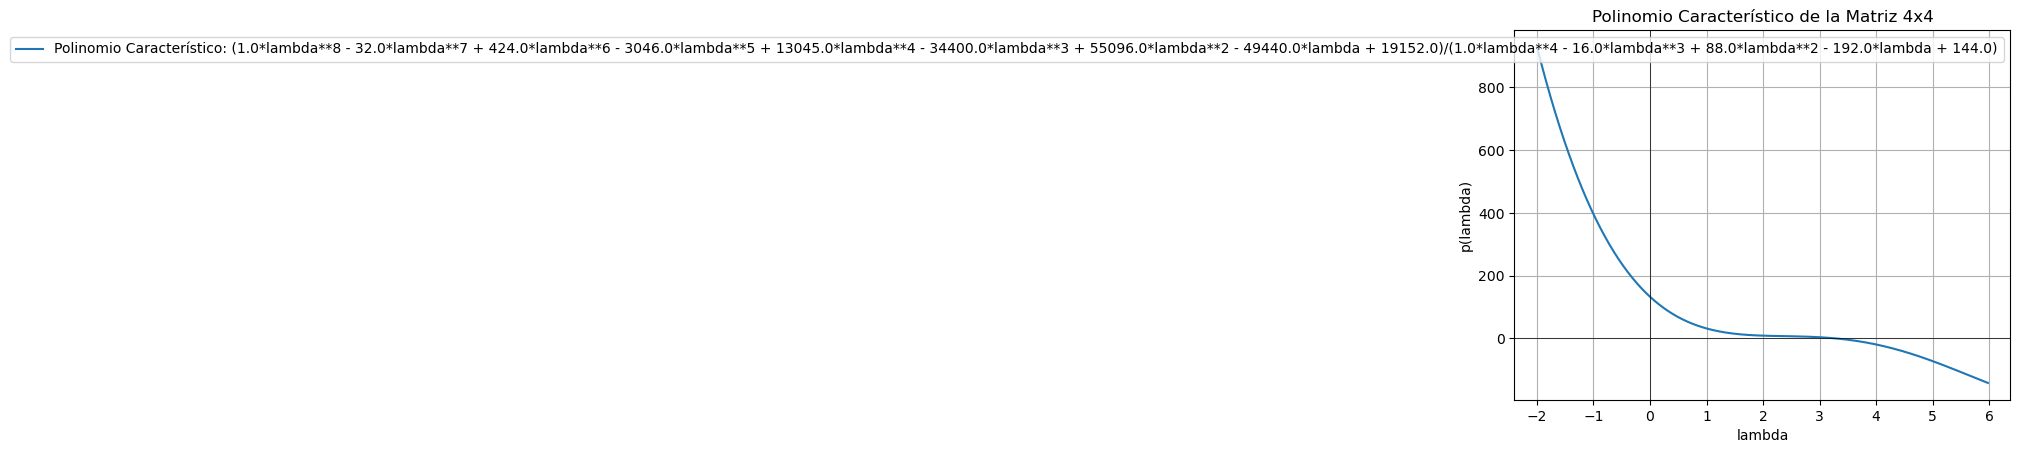

In [ ]:
# Ejercicio 8
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Definir la matriz
A = np.array([[4, 4, 2, 1], [1, 4, 2, 2], [2, 1, 4, 1], [1, 2, 1, 4]])

# Calcular el polinomio característico
lambda_var = sp.Symbol('lambda')
I = np.eye(4)
char_poly = sp.Matrix(A - lambda_var * I).det()

# Simplificar y mostrar el polinomio característico
char_poly = sp.simplify(char_poly)
print(f"Polinomio Característico: {char_poly}")

# Graficar el polinomio característico
p = sp.lambdify(lambda_var, char_poly, 'numpy')
x = np.linspace(-2, 6, 400)
y = p(x)

plt.figure()
plt.plot(x, y, label=f'Polinomio Característico: {char_poly}')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('lambda')
plt.ylabel('p(lambda)')
plt.title('Polinomio Característico de la Matriz 4x4')
plt.legend()
plt.grid(True)
plt.show()

Polinomio Característico: -1.0*lambda**3 + 9.0*lambda**2 - 14.0*lambda + 3


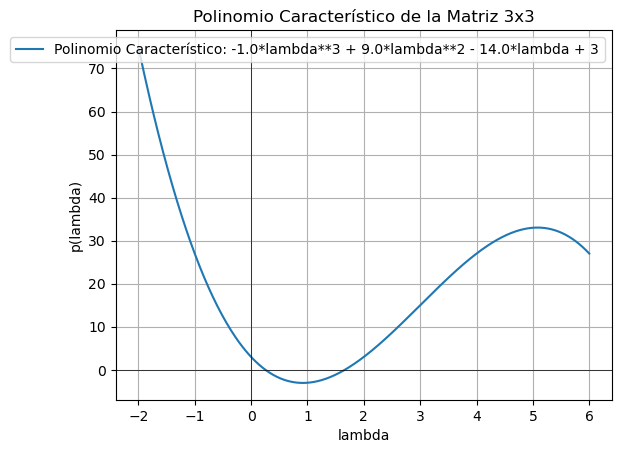

In [ ]:
# Ejercicio 9
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Definir la matriz
A = np.array([[3, 1, 3], [2, 3, 1], [3, 2, 3]])

# Calcular el polinomio característico
lambda_var = sp.Symbol('lambda')
I = np.eye(3)
char_poly = sp.Matrix(A - lambda_var * I).det()

# Simplificar y mostrar el polinomio característico
char_poly = sp.simplify(char_poly)
print(f"Polinomio Característico: {char_poly}")

# Graficar el polinomio característico
p = sp.lambdify(lambda_var, char_poly, 'numpy')
x = np.linspace(-2, 6, 400)
y = p(x)

plt.figure()
plt.plot(x, y, label=f'Polinomio Característico: {char_poly}')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('lambda')
plt.ylabel('p(lambda)')
plt.title('Polinomio Característico de la Matriz 3x3')
plt.legend()
plt.grid(True)
plt.show()

### 8.4.

In [ ]:
# Ejercicio 10
import numpy as np

def diagonalize_matrix(A):
    """
    Función para diagonalizar una matriz.
    Parámetros:
    A (numpy.ndarray): La matriz cuadrada que se desea diagonalizar.
    Retorna:
    P (numpy.ndarray): La matriz de autovectores.
    D (numpy.ndarray): La matriz diagonal de autovalores.
    """
    # Cálculo de autovalores y autovectores
    eigenvalues, eigenvectors = np.linalg.eig(A)

    # Formar la matriz diagonal D
    D = np.diag(eigenvalues)

    # Formar la matriz P de autovectores
    P = eigenvectors

    # Verificación de la diagonalización
    P_inv = np.linalg.inv(P)
    A_reconstructed = P @ D @ P_inv
    return P, D, A_reconstructed

# Ejemplo de uso con una matriz 2x2
A = np.array([[4, 1],
              [2, 3]])
P, D, A_reconstructed = diagonalize_matrix(A)

print("Matriz original A:")
print(A)
print("\nMatriz de autovectores P:")
print(P)
print("\nMatriz diagonal D:")
print(D)
print("\nReconstrucción de A a partir de PDP^-1:")
print(A_reconstructed)

# Verificación de la diagonalización
print("\nA es aproximadamente igual a PDP^-1?")
print(np.allclose(A, A_reconstructed))

Matriz original A:
[[4 1]
 [2 3]]

Matriz de autovectores P:
[[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]

Matriz diagonal D:
[[5. 0.]
 [0. 2.]]

Reconstrucción de A a partir de PDP^-1:
[[4. 1.]
 [2. 3.]]

A es aproximadamente igual a PDP^-1?
True


### FIN